In [7]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
iris = load_iris()
X = iris.data
y = iris.target

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_dim=4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.1)

Epoch 1/100
7/7 [==============================] - 1s 41ms/step - loss: 1.0141 - accuracy: 0.4722 - val_loss: 1.0429 - val_accuracy: 0.4167
Epoch 2/100
7/7 [==============================] - 0s 9ms/step - loss: 0.8857 - accuracy: 0.6667 - val_loss: 0.9644 - val_accuracy: 0.5000
Epoch 3/100
7/7 [==============================] - 0s 6ms/step - loss: 0.7866 - accuracy: 0.6759 - val_loss: 0.9048 - val_accuracy: 0.5000
Epoch 4/100
7/7 [==============================] - 0s 6ms/step - loss: 0.6999 - accuracy: 0.6852 - val_loss: 0.8539 - val_accuracy: 0.5000
Epoch 5/100
7/7 [==============================] - 0s 5ms/step - loss: 0.6358 - accuracy: 0.7130 - val_loss: 0.8054 - val_accuracy: 0.5000
Epoch 6/100
7/7 [==============================] - 0s 5ms/step - loss: 0.5789 - accuracy: 0.7315 - val_loss: 0.7537 - val_accuracy: 0.5833
Epoch 7/100
7/7 [==============================] - 0s 6ms/step - loss: 0.5335 - accuracy: 0.7685 - val_loss: 0.7071 - val_accuracy: 0.6667
Epoch 8/100
7/7 [=========

In [16]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test loss: {loss:.4f}, Test accuracy: {accuracy:.4f}")

1/1 [==============================] - 0s 21ms/step - loss: 0.0135 - accuracy: 1.0000
Test loss: 0.0135, Test accuracy: 1.0000


Epoch 1/100
7/7 [==============================] - 0s 11ms/step - loss: 0.0089 - accuracy: 1.0000 - val_loss: 0.8693 - val_accuracy: 0.9167
Epoch 2/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0084 - accuracy: 1.0000 - val_loss: 0.8826 - val_accuracy: 0.9167
Epoch 3/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0080 - accuracy: 1.0000 - val_loss: 0.9080 - val_accuracy: 0.9167
Epoch 4/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0079 - accuracy: 1.0000 - val_loss: 0.9037 - val_accuracy: 0.9167
Epoch 5/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0077 - accuracy: 1.0000 - val_loss: 0.8993 - val_accuracy: 0.9167
Epoch 6/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0089 - accuracy: 1.0000 - val_loss: 0.8844 - val_accuracy: 0.9167
Epoch 7/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0073 - accuracy: 1.0000 - val_loss: 0.9226 - val_accuracy: 0.9167
Epoch 8/100
7/7 [=========

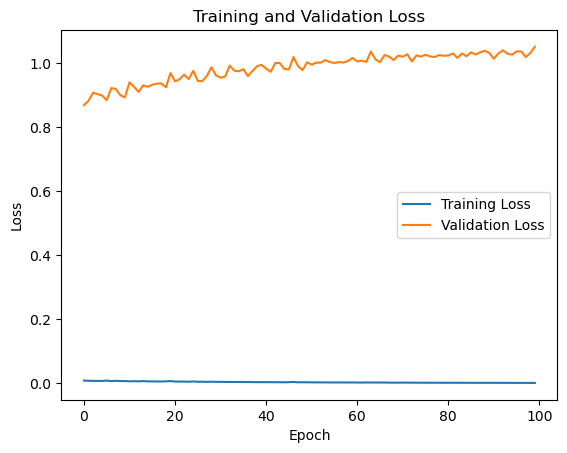

In [18]:
import matplotlib.pyplot as plt

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.1)


loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test loss: {loss:.4f}, Test accuracy: {accuracy:.4f}")

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()